In [101]:
# import os
# import numpy as np
# np.int = int

# import cv2
# from insightface.app import FaceAnalysis
# import matplotlib.pyplot as plt

# app = FaceAnalysis(
#     name="buffalo_l",
#     providers=["CPUExecutionProvider", "CUDAExecutionProvider"]
# )
# app.prepare(ctx_id=0)

# image_dir = "testimage"
# emb_list = []
# img_names = []

# for fname in os.listdir(image_dir):
#     path = os.path.join(image_dir, fname)
#     img = cv2.imread(path)

#     faces = app.get(img)

#     if len(faces) > 0:
#         emb_list.append(faces[0].embedding)
#         img_names.append(fname)

# emb_array = np.stack(emb_list)

# np.save("embeddings.npy", emb_array)

# rimg = app.draw_on(img, faces)
# plt.imshow(cv2.cvtColor(rimg, cv2.COLOR_BGR2RGB))
# plt.axis("off")
# # cv2.imwrite("t1_output.jpg", rimg)

# plt.figure(figsize=(12, 1.8))
# plt.imshow(emb_array[np.newaxis, :], aspect="auto", cmap="viridis")
# plt.colorbar()
# plt.yticks([])
# plt.title("ArcFace 512-D Embedding")
# plt.xlabel("Feature Dimension")
# plt.tight_layout()
# # plt.savefig("embedding_heatmap.png", dpi=300)
# plt.show()



Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/kxu56/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], 

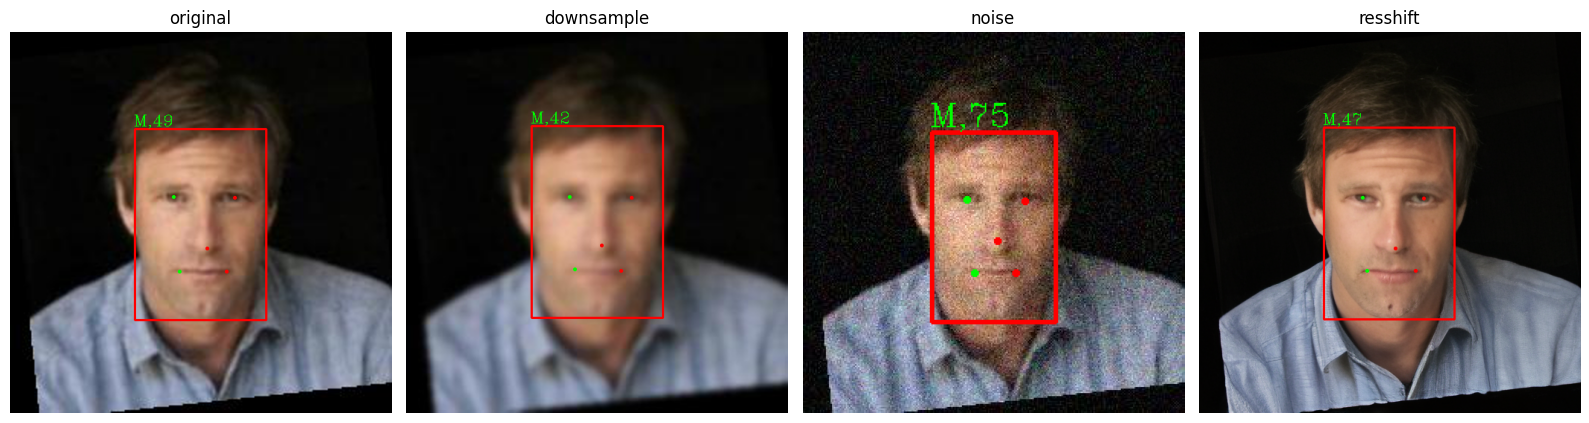

Cosine Similarities:
original vs downsample: 0.9228
original vs noise: 0.8366
original vs resshift: 0.8677


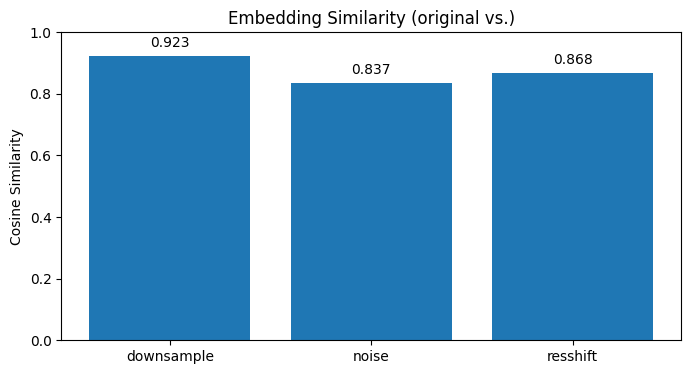

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis

np.int = int

app = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)
app.prepare(ctx_id=0, det_size=(640, 640))


original_path = "testimage/original.png"
downsample_path = "testimage/downsample.png"
noise_path = "testimage/noise.jpg"
resshift_path = "testimage/resshift.png"


def get_face_info(img_path, label):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Failed to read image: {img_path}")

    faces = app.get(img)
    if len(faces) == 0:
        raise ValueError(f"No face detected in {label}: {img_path}")

    face = faces[0]

    draw_img = app.draw_on(img.copy(), faces)
    draw_img = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

    emb = face.embedding.astype(np.float32)

    return {
        "label": label,
        "img": img,
        "draw_img": draw_img,
        "embedding": emb,
        "faces": faces
    }

def cosine_similarity(a, b):
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)
    return float(np.dot(a, b))


original_info = get_face_info(original_path, "original")
downsample_info = get_face_info(downsample_path, "downsample")
noise_info = get_face_info(noise_path, "noise")
resshift_info = get_face_info(resshift_path, "resshift")

infos = [
    original_info,
    downsample_info,
    noise_info,
    resshift_info
]


fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, info in enumerate(infos):
    axes[i].imshow(info["draw_img"])
    axes[i].set_title(info["label"])
    axes[i].axis("off")

# fig.suptitle("Face Detection Results", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("drawon_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# similarity
sim_original_downsample = cosine_similarity(original_info["embedding"], downsample_info["embedding"])
sim_original_noise = cosine_similarity(original_info["embedding"], noise_info["embedding"])
sim_original_resshift = cosine_similarity(original_info["embedding"], resshift_info["embedding"])

print("Cosine Similarities:")
print(f"original vs downsample: {sim_original_downsample:.4f}")
print(f"original vs noise: {sim_original_noise:.4f}")
print(f"original vs resshift: {sim_original_resshift:.4f}")

pairs = [
    "downsample",
    "noise",
    "resshift",
]
values = [
    sim_original_downsample,
    sim_original_noise,
    sim_original_resshift,
]

plt.figure(figsize=(8, 4))
bars = plt.bar(pairs, values)
plt.ylim(0, 1.0)
plt.ylabel("Cosine Similarity")
plt.title("Embedding Similarity (original vs.)")

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.02,
        f"{v:.3f}",
        ha="center",
        va="bottom"
    )

# plt.xticks(rotation=15)
# plt.tight_layout()
plt.savefig("embedding_similarity.png", dpi=300, bbox_inches="tight")
plt.show()

In [103]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# import numpy as np

# original_info["embedding"],
# downsample_info["embedding"],
# noise_info["embedding"],
# resshift_info["embedding"]
# # 三个embedding
# emb_clean = original_info["embedding"]
# emb_deg = downsample_info["embedding"]
# emb_res = resshift_info["embedding"]

# X = np.stack([emb_clean, emb_deg, emb_res])

# # PCA降到2D
# pca = PCA(n_components=2)
# X_2d = pca.fit_transform(X)

# labels = ["Clean", "Degraded", "Restored"]
# colors = ["green", "red", "blue"]

# plt.figure(figsize=(6,6))

# for i in range(3):
#     plt.scatter(X_2d[i,0], X_2d[i,1],
#                 color=colors[i],
#                 label=labels[i],
#                 s=120)

#     plt.text(X_2d[i,0]+0.01, X_2d[i,1]+0.01, labels[i])

# plt.title("2D Visualization of ArcFace Embeddings (PCA)")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.savefig("embedding_pca.png", dpi=300)
# plt.show()

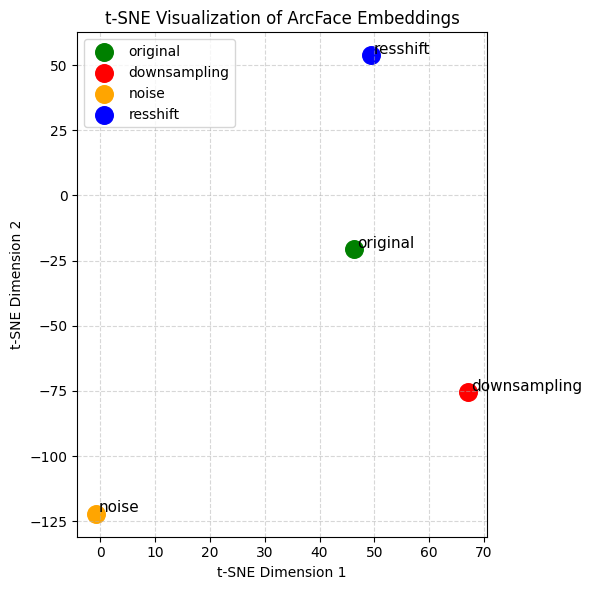

In [ ]:
from sklearn.manifold import TSNE

X = np.stack([
    original_info["embedding"],
    downsample_info["embedding"],
    noise_info["embedding"],
    resshift_info["embedding"]
], axis=0)

labels = ["original", "downsampling", "noise", "resshift"]
colors = {
    "original": "green",
    "downsampling": "red",
    "noise": "orange",
    "resshift": "blue"
}

tsne = TSNE(
    n_components=2,
    perplexity=2,
    random_state=0,
    init="pca",
    learning_rate="auto"
)

X_2d = tsne.fit_transform(X)

plt.figure(figsize=(6, 6))

for i, label in enumerate(labels):
    plt.scatter(
        X_2d[i, 0],
        X_2d[i, 1],
        color=colors[label],
        s=160,
        label=label
    )
    plt.text(
        X_2d[i, 0] + 0.5,
        X_2d[i, 1] + 0.5,
        label,
        fontsize=11
    )

plt.title("t-SNE Visualization of ArcFace Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("embedding_tsne.png", dpi=300, bbox_inches="tight")
plt.show()

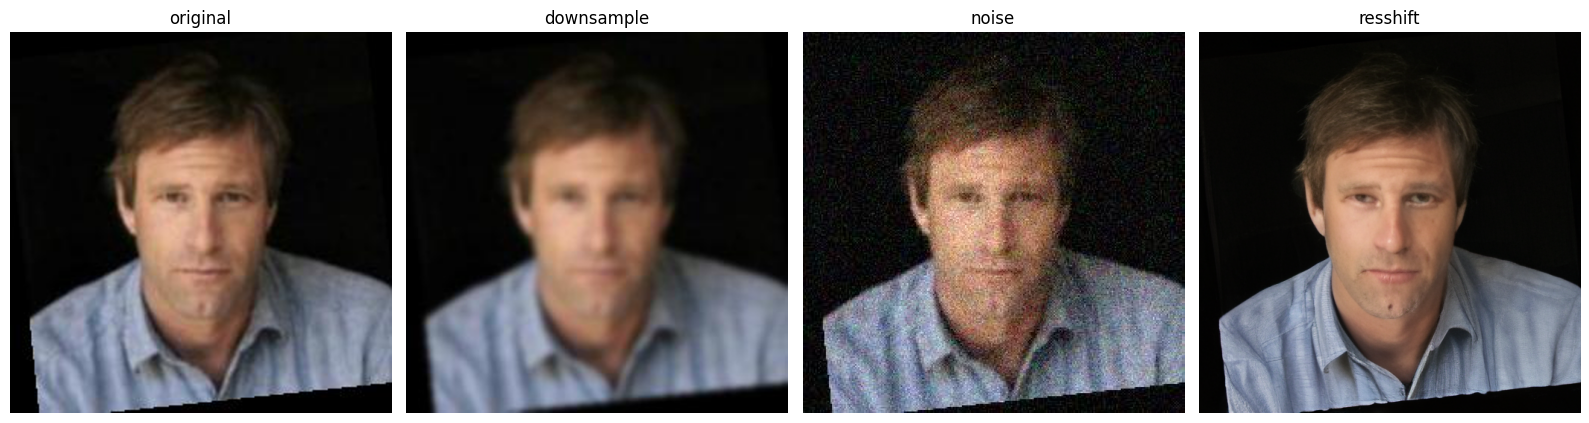

In [110]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, info in enumerate(infos):
    img = cv2.cvtColor(info["img"], cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(info["label"])
    axes[i].axis("off")

# fig.suptitle("Face Detection Results", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("img.png", dpi=300, bbox_inches="tight")
plt.show()